# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["XOM", "UPS", "PEP"]
sectores = {}
justificaciones = {}

print("Librerías listas. El portafolio empieza con:", tickers)

Librerías listas. El portafolio empieza con: ['XOM', 'UPS', 'PEP']


In [14]:
# Paso 1: Descarga de Datos Históricos
# Periodo: 1 de enero de 2024 al 1 de enero de 2026

start_date = "2024-01-01"
end_date = "2026-01-01"

# Descargar datos históricos utilizando yfinance
datos = yf.download(tickers, start=start_date, end=end_date)

# Mostrar las primeras 5 filas del DataFrame
datos.head()

/tmp/ipykernel_2336/3995772983.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed


Price            Close                               High              \
Ticker             PEP         UPS        XOM         PEP         UPS   
Date                                                                    
2024-01-02  156.347290  134.933273  93.601608  156.419629  136.791020   
2024-01-03  156.383484  134.251541  94.388039  158.417961  135.742846   
2024-01-04  155.045227  133.782867  93.565025  156.907901  134.916261   
2024-01-05  152.757584  135.257111  93.848495  155.135666  135.887724   
2024-01-08  152.911301  136.279694  92.284813  153.471908  136.339352   

Price                         Low                               Open  \
Ticker            XOM         PEP         UPS        XOM         PEP   
Date                                                                   
2024-01-02  94.278289  152.983621  133.194843  92.220809  153.282012   
2024-01-03  94.753814  156.157431  133.092584  92.961521  158.237121   
2024-01-04  95.622505  154.240479  133.288605  93.318131  155.171816   
2024-01-05  94.552615  151.509767  133.152239  93.391278  155.135666   
2024-01-08  92.394548  151.717734  134.200387  90.437657  152.757586   

Price                               Volume                     
Ticker             UPS        XOM      PEP      UPS       XOM  
Date                                                           
2024-01-02  133.740235  92.284819  5743100  4363800  23483000  
2024-01-03  134.021463  93.519321  5588200  3257200  23490800  
2024-01-04  133.833996  95.174434  6283200  3173400  19395200  
2024-01-05  133.297107  94.342291  5252500  2537300  15827400  
2024-01-08  135.129266  92.111075  5735600  2469500  23370100

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

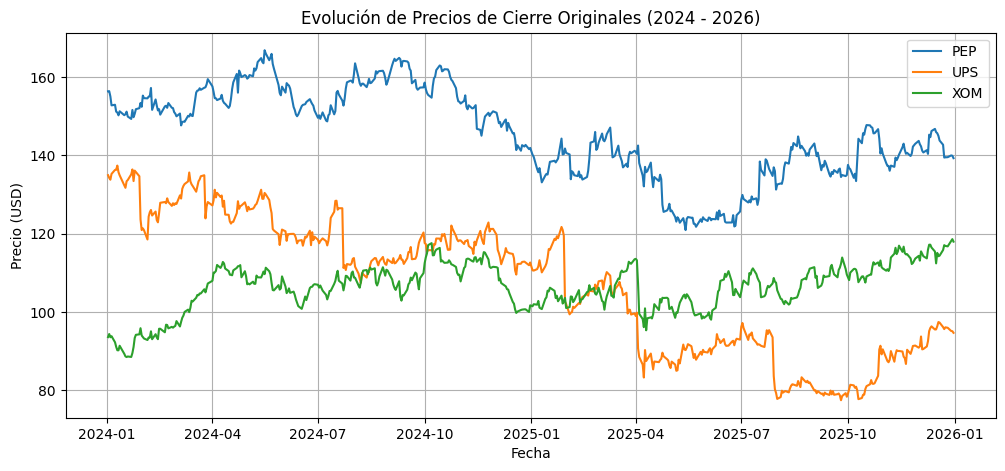

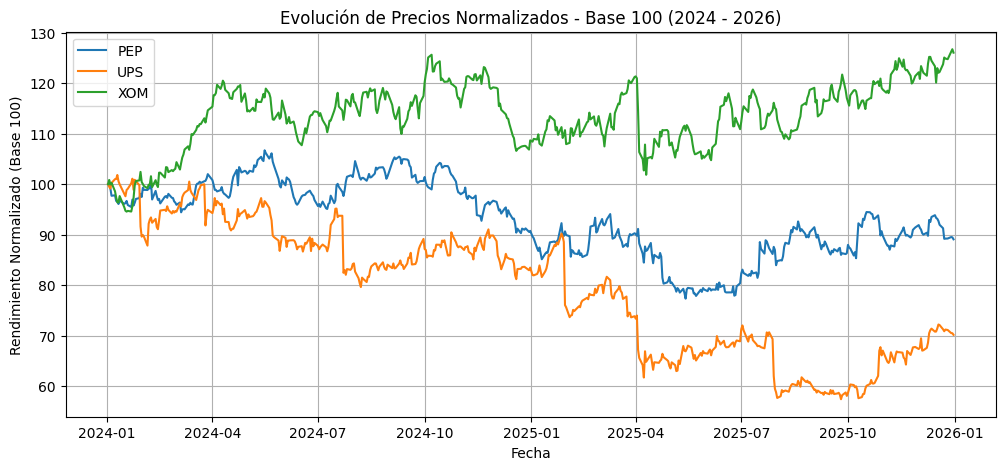

In [15]:
# 1. Extraer los precios de cierre
precios_cierre = datos['Close']

# 2. Graficar precios originales
plt.figure(figsize=(12, 5))
for col in precios_cierre.columns:
    plt.plot(precios_cierre.index, precios_cierre[col], label=col)
plt.title('Evolución de Precios de Cierre Originales (2024 - 2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Normalizar y graficar en base 100
precios_normalizados = (precios_cierre / precios_cierre.iloc[0]) * 100

plt.figure(figsize=(12, 5))
for col in precios_normalizados.columns:
    plt.plot(precios_normalizados.index, precios_normalizados[col], label=col)
plt.title('Evolución de Precios Normalizados - Base 100 (2024 - 2026)')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Normalizado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

Desviaciones estándar (volatilidad diaria):
Ticker
PEP    0.012438
UPS    0.018767
XOM    0.013455
dtype: float64

El activo más volátil es: UPS



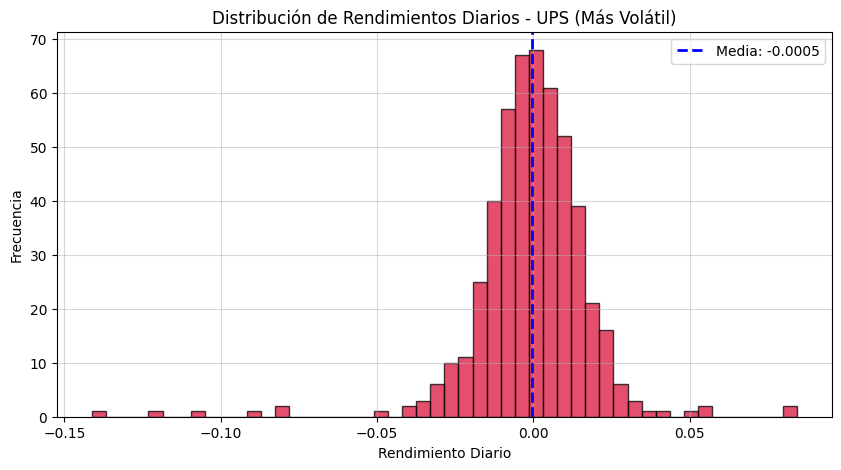

/tmp/ipykernel_2336/1230978321.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rendimientos[col] for col in rendimientos.columns], labels=rendimientos.columns, patch_artist=True,


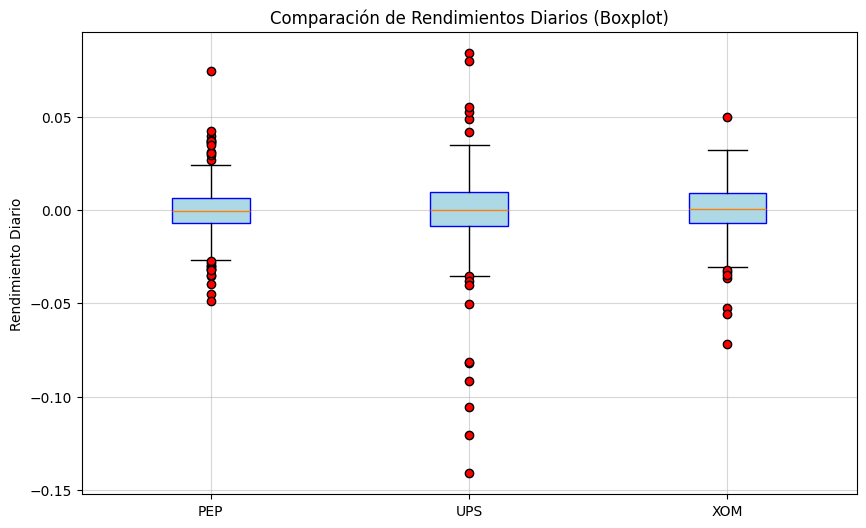

In [17]:
# 1. Calcular rendimientos diarios y eliminar valores nulos (NaN)
rendimientos = precios_cierre.pct_change().dropna()

# Identificar el activo más volátil mediante la desviación estándar
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()
print(f"Desviaciones estándar (volatilidad diaria):\n{volatilidad}\n")
print(f"El activo más volátil es: {activo_mas_volatil}\n")

# 2. Histograma con el activo más volátil
plt.figure(figsize=(10, 5))
plt.hist(rendimientos[activo_mas_volatil], bins=50, color='crimson', edgecolor='black', alpha=0.75)
plt.axvline(rendimientos[activo_mas_volatil].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Media: {rendimientos[activo_mas_volatil].mean():.4f}')
plt.title(f'Distribución de Rendimientos Diarios - {activo_mas_volatil} (Más Volátil)')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# 3. Boxplot comparativo de rendimientos para los 3 activos
plt.figure(figsize=(10, 6))
plt.boxplot([rendimientos[col] for col in rendimientos.columns], labels=rendimientos.columns, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none'))
plt.title('Comparación de Rendimientos Diarios (Boxplot)')
plt.ylabel('Rendimiento Diario')
plt.grid(True, alpha=0.5)
plt.show()

1.UPS presenta la mayor dispersion osea que los rendimientos diarios flutuan much mas, osea mayor riesgo y votabilidad
2. hay una caida de casi -15en upsque son como reacciones de euforia en el mercaod ante eventos especificos de gran impacto

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Matriz de Correlación de Pearson:
 Ticker       PEP       UPS       XOM
Ticker                              
PEP     1.000000  0.182339  0.149886
UPS     0.182339  1.000000  0.257468
XOM     0.149886  0.257468  1.000000 



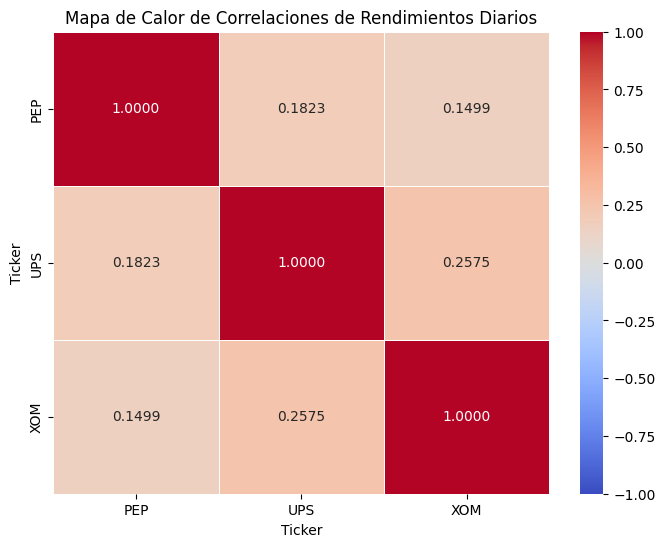

In [18]:
import seaborn as sns

# 1. Calcular matriz de correlación
matriz_corr = rendimientos.corr(method='pearson')
print("Matriz de Correlación de Pearson:\n", matriz_corr, "\n")

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".4f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones de Rendimientos Diarios')
plt.show()

### 💬 Interpretación Analítica - Paso 4

* **¿Existe alguna correlación fuerte entre los activos?**
  * **No.** Todas las correlaciones entre los rendimientos diarios de los tres activos son **muy débiles** (todas inferiores a $0.30$):
    * **PEP y XOM:** $0.1499$ (correlación casi nula).
    * **PEP y UPS:** $0.1823$ (correlación muy débil).
    * **UPS y XOM:** $0.2575$ (correlación débil).
  
* **¿Qué par de activos elegirías para armar un portafolio de inversión buscando la máxima diversificación?**
  * El par óptimo para diversificar es **PEP y XOM** debido a que presentan la correlación más baja del portafolio ($0.1499$).
  * **Justificación económica:** Una correlación tan baja indica que los rendimientos de PepsiCo (consumo defensivo) y ExxonMobil (energía) se mueven de manera casi independiente. Si el sector energético (XOM) sufre caídas por la baja en los precios del petróleo, el sector de consumo masivo (PEP) no se verá afectado de la misma manera, amortiguando eficazmente el riesgo conjunto del portafolio.

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [23]:
# Generar resumen de estadísticas descriptivas completas
resumen_estadistico = rendimientos.agg(['mean', 'median', 'std', 'min', 'max']).T
resumen_estadistico.columns = ['Media', 'Mediana', 'Desviación Estándar', 'Mínimo', 'Máximo']

print("--- Resumen Estadístico de Rendimientos Diarios ---")
display(resumen_estadistico)

--- Resumen Estadístico de Rendimientos Diarios ---


,Media,Mediana,Desviación Estándar,Mínimo,Máximo
Ticker,,,,,
PEP,-0.000154,-0.000538,0.012438,-0.048854,0.074547
UPS,-0.000526,0.000000,0.018767,-0.141127,0.084204
XOM,0.000553,0.000583,0.013455,-0.071956,0.049916


### 💬 Conclusión del Análisis - Paso 5 (Interpretación de `resumen_estadistico`)

De acuerdo con la tabla generada en `resumen_estadistico`, podemos extraer las siguientes conclusiones clave orientadas a la toma de decisiones de inversión:

* **Desviación Estándar (Volatilidad y Riesgo):**
  * **UPS** presenta la mayor **Desviación Estándar (1.8767%)**, lo que la posiciona como la opción de mayor riesgo del portafolio. Esto se alinea con su rendimiento máximo (**8.42%**) y su peor rendimiento mínimo de (**-14.11%**).
  * **PEP** cuenta con la menor **Desviación Estándar (1.2438%)**, confirmando su naturaleza como un activo de perfil defensivo y estable.
  * **XOM** mantiene un riesgo intermedio con una volatilidad de **1.3455%**.

* **Rendimiento Diario Promedio (Media y Mediana):**
  * **XOM** es el único activo que logró una media positiva (**+0.0553%** diaria), superando consistentemente a sus pares durante el periodo analizado.
  * **UPS** y **PEP** registraron medias marginalmente negativas, lo que indica un ciclo correctivo o de contracción para estas compañías entre 2024 y 2026.

* **Recomendación para el Inversionista:**
  Se sugiere estructurar un portafolio combinando **XOM** (para capturar retornos positivos) y **PEP** (para actuar como un amortiguador de volatilidad gracias a su baja desviación estándar), reduciendo la ponderación en **UPS** debido a su elevado riesgo asimétrico durante este ciclo económico.